Missing Values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Summary Statistics:
              crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis       

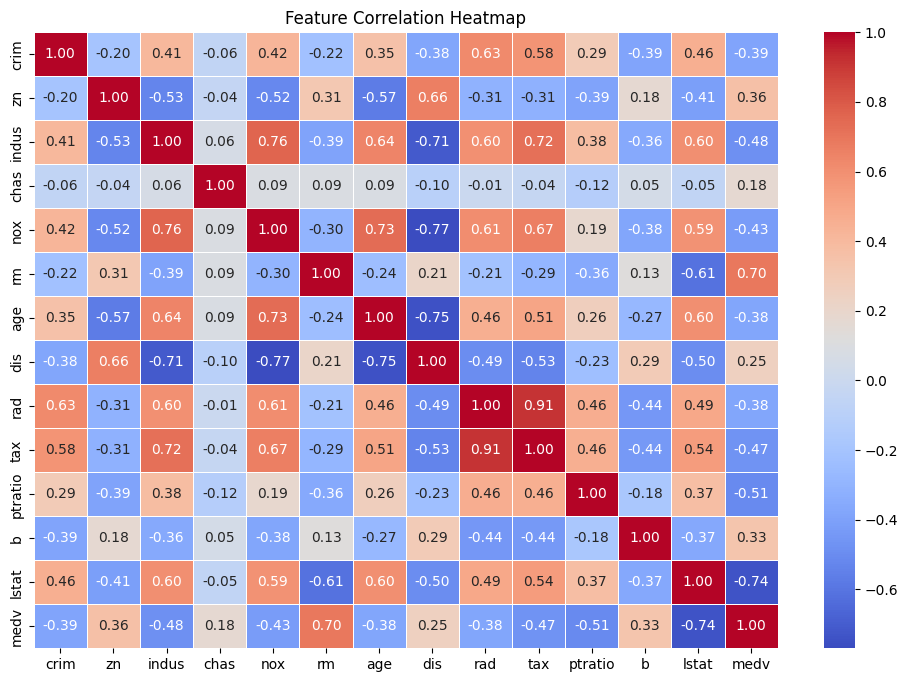

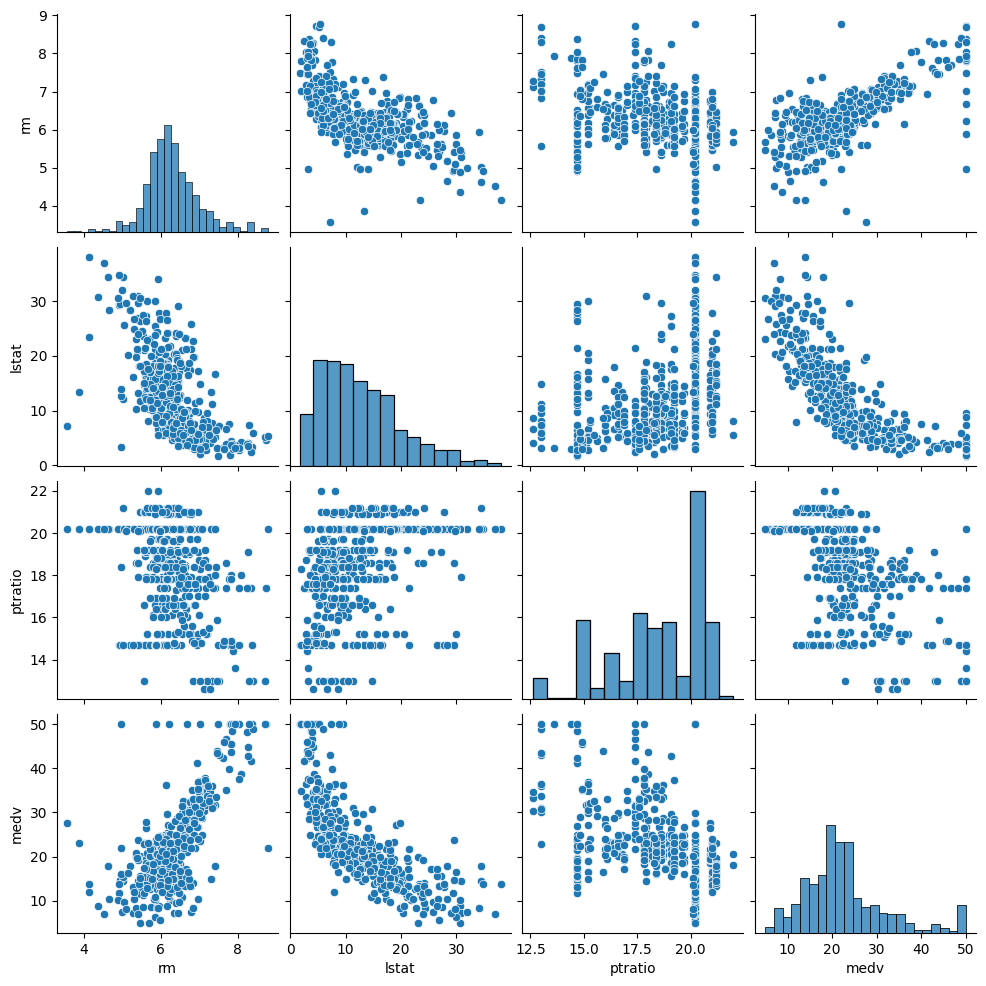

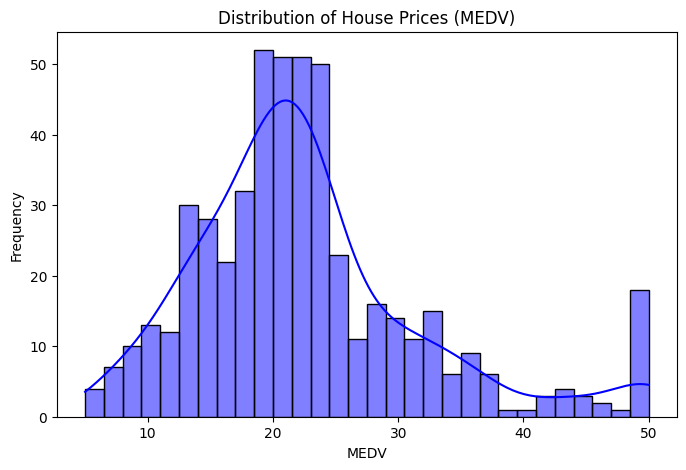

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/boston.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['medv'], bins=30, kde=True, color='blue')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [73]:
x=df.drop(columns=['medv'])  #define features
y=df["medv"]   #define target

In [74]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) #42 to avoid favourism

In [75]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [76]:
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)

In [77]:
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286


In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

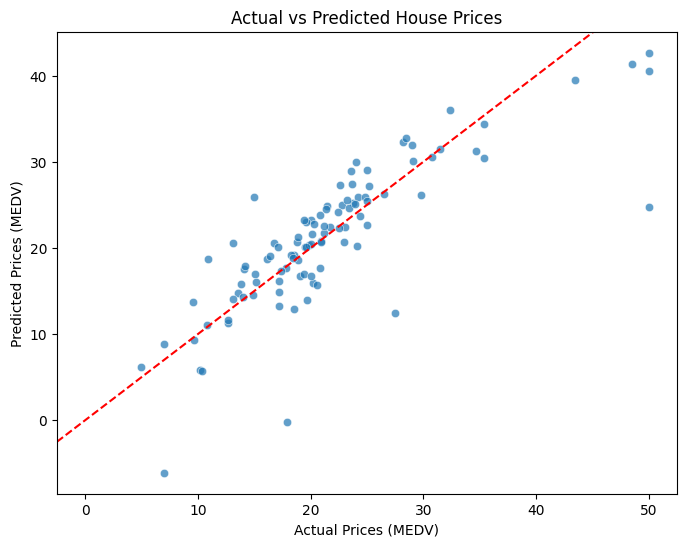

In [79]:
from matplotlib import lines
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices (MEDV)")
plt.title("Actual vs Predicted House Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [80]:
from scipy.stats import skew

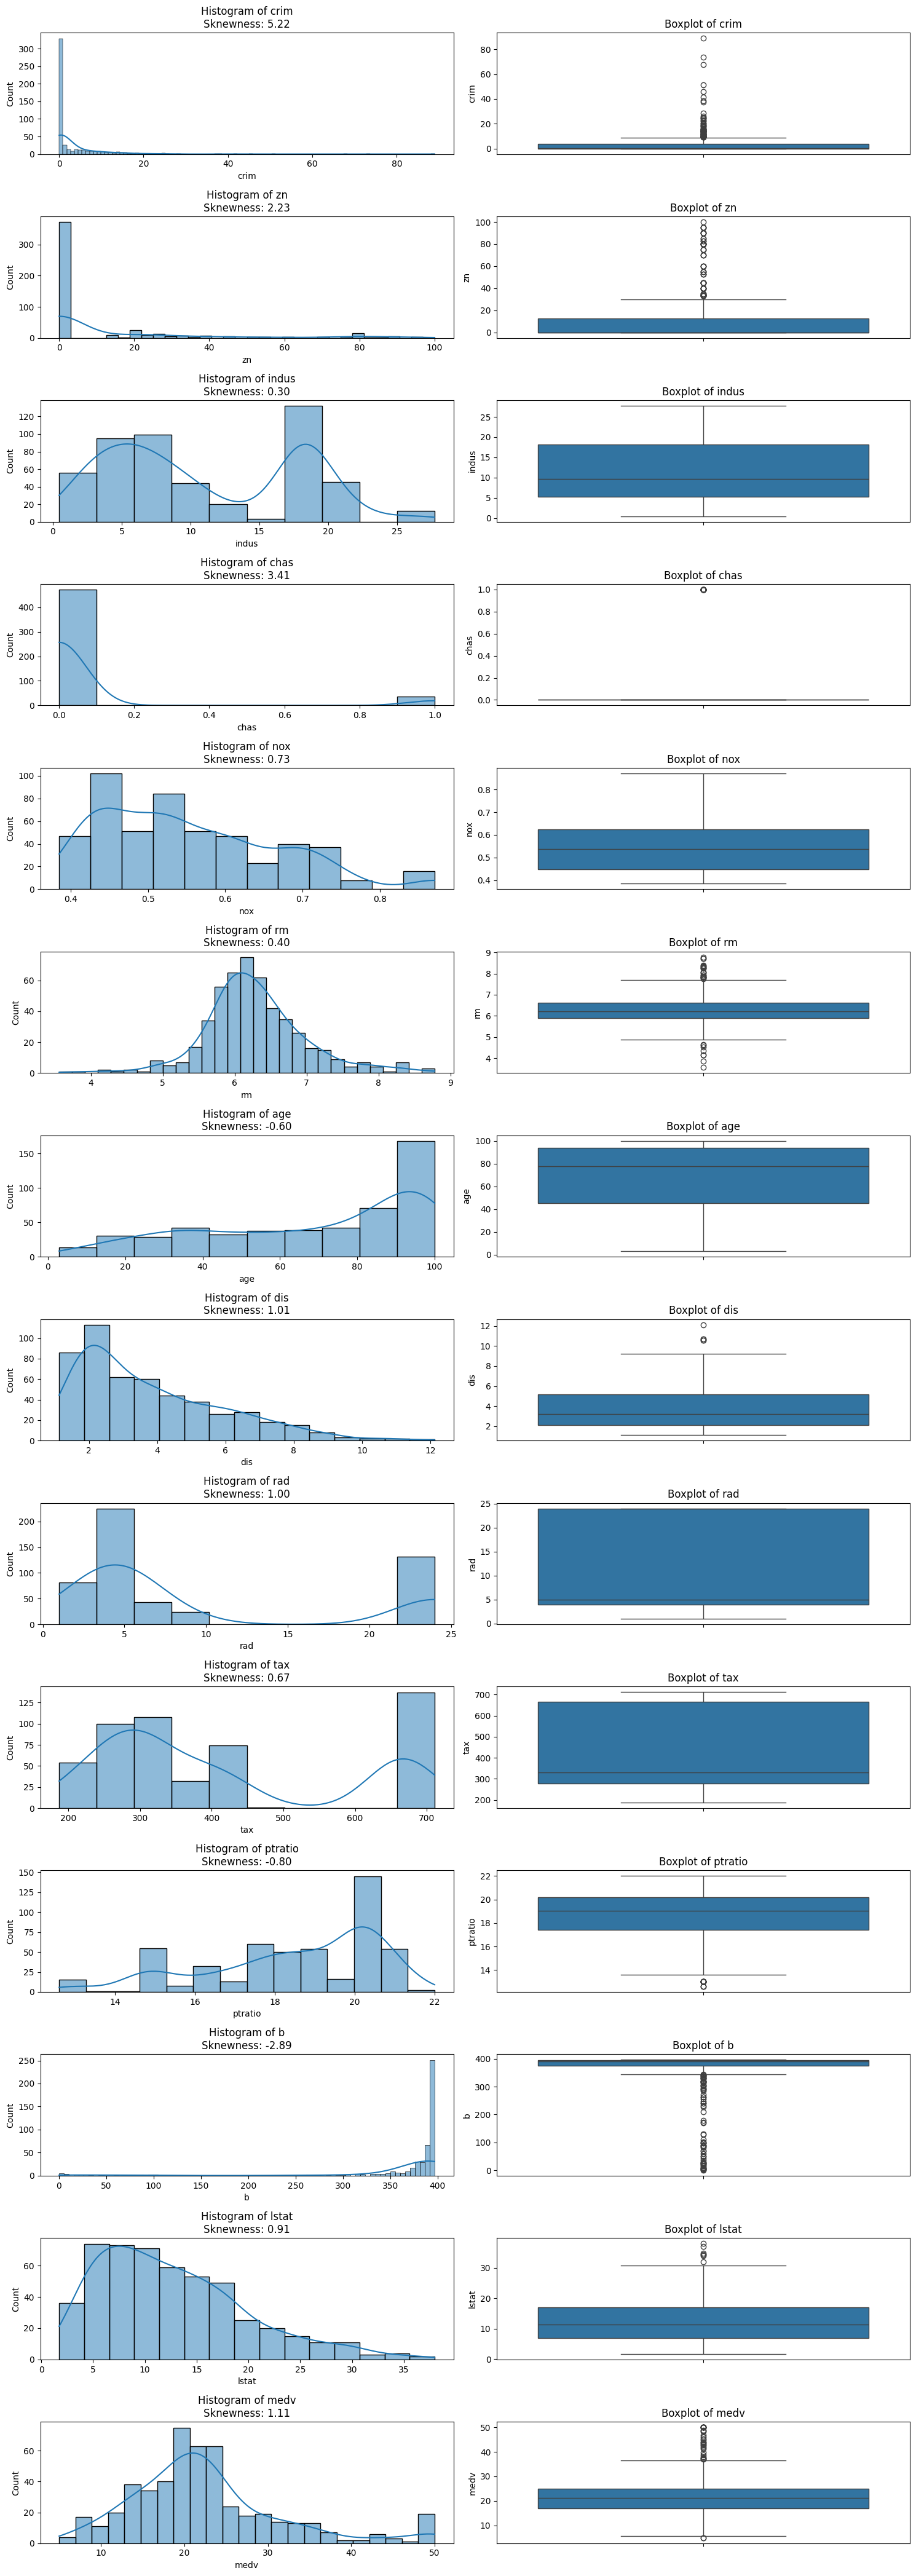

In [81]:

skewness=df.skew()
num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))
for i, col in enumerate(df.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f'Histogram of {col}\nSknewness: {skewness[col]:.2f}')
  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(df[col])
  plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [82]:
print(skewness)

crim       5.223149
zn         2.225666
indus      0.295022
chas       3.405904
nox        0.729308
rm         0.403612
age       -0.598963
dis        1.011781
rad        1.004815
tax        0.669956
ptratio   -0.802325
b         -2.890374
lstat      0.906460
medv       1.108098
dtype: float64


In [83]:
import numpy as np

In [84]:
#to find skewed colums
skewed_cols=df.skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')
Negatively Skewed Columns:
 Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat'], dtype='object')


In [85]:
#to remove high sknewness
df[highly_skewed]=df[highly_skewed].apply(lambda x: np.log1p(x))

In [86]:
#to remove low skewness
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [87]:
skewness=df.skew()
print(skewness)

crim       1.269201
zn         1.193451
indus     -0.104641
chas       3.405904
nox        0.098431
rm         0.023275
age       -0.417736
dis        0.331561
rad        0.532760
tax        0.079613
ptratio   -0.220097
b         -4.459061
lstat     -0.017928
medv      -0.241244
dtype: float64


In [88]:
x=df.drop(columns=['medv'])  #define features
y=df["medv"]   #define target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}") #performance rate
print(f"RMSE: {rmse:.4f}") #error rate

R² Score: 0.7555
RMSE: 0.1842


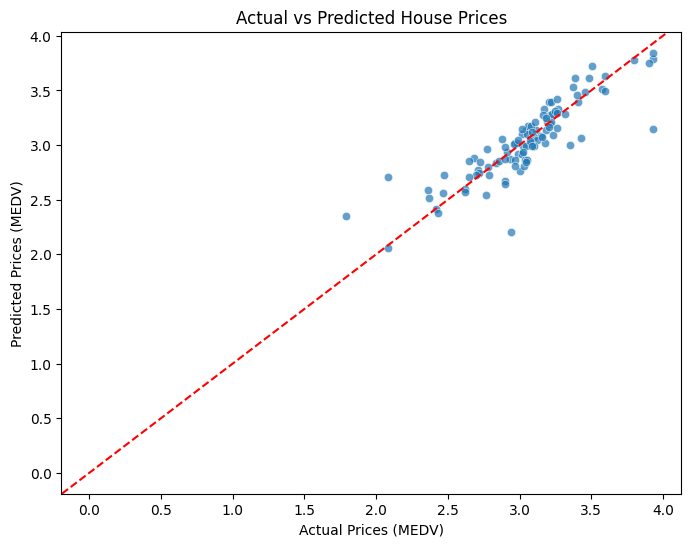

In [89]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices (MEDV)")
plt.title("Actual vs Predicted House Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [91]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train,y_train)
y_pred=rf_model.predict(x_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print(f'Random Forest R2 Score: {r2:.4f}')
print(f'Random Forest RMSE: {rmse:.4f}')

Random Forest R2 Score: 0.8409
Random Forest RMSE: 0.1485
